# HW3 - Problem 2: Departure-delay classification

**Question:** Can a neural network predict whether a flight will depart at least
15 minutes late, using information available from its booking or itinerary?
I define `DepDel15 = 1` when `DEP_DELAY >= 15`, and 0 otherwise. The 15-minute
target is fixed; the probability cutoff used to make a prediction is a separate choice.

This continues HW1's departure-delay study and HW2's binary classification problem.
I use the same BTS extract and seven source predictors: weekday, airline, origin,
destination, scheduled departure time, scheduled duration, and distance. Actual
departure delay creates the target and never enters the predictors. I add no
weather data, actual flight times, or other information observed after departure.

I compare a PyTorch feedforward neural network with KNN and logistic regression.
The notebook defines and imports the data, fits all three models, presents a
training curve and test error, and discusses their usefulness, as required by
`README.md`, Problem 2. AUC, precision, recall, and confusion matrices continue
the evaluation used in HW2.

## Run this notebook

Keep the supplied `T_ONTIME_REPORTING.csv` beside this notebook, install
`requirements.txt` and Jupyter, restart the kernel, and run all cells in order.
No other notebook, saved model, or absolute path is needed. Submit the CSV with
the notebooks so the results can be reproduced.

The default uses all eligible training rows, with separate 10,000-row samples
for model selection, cutoff calibration, and final testing. The final search
compares eight simple neural networks, fourteen K values, and seven logistic
regularization settings. It takes several minutes on CPU. `SAMPLE_SIZE` can
limit training rows while leaving all holdouts fixed; rerun everything after
changing a setting. CPU execution, fixed seeds and thread counts, and deterministic
PyTorch operations support repeatability. Exact results may change across
library versions or platforms; versions are printed below.

In [1]:
from pathlib import Path
import copy
import hashlib
import platform
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy.sparse import hstack
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from threadpoolctl import threadpool_limits
import torch
from torch import nn
from IPython.display import Markdown, display

CSV_PATH = Path("T_ONTIME_REPORTING.csv")
EXPECTED_SHA256 = "e8f309714c1133d2a29ab383d3d7a290113820d8eda061a457338b1f27620846"
SAMPLE_SIZE = None
VALIDATION_SIZE = 10000
CALIBRATION_SIZE = 10000
TEST_SIZE = 10000
SEED = 42
HOLDOUT_SEED = 2026
TIME_BIN_HOURS = 3

K_VALUES = [1, 3, 5, 9, 15, 21, 31, 51, 101, 201, 301, 501, 701, 1001]
C_VALUES = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
MAX_EPOCHS = 120
MIN_EPOCHS = 30
PATIENCE = 20
BATCH_SIZE = 1024
MOMENTUM = 0.9

# (Hidden units, learning rate, L2 weight decay), declared before testing.
NN_CONFIGS = [
    (32, 0.05, 0.0001), (64, 0.03, 0.0001), (64, 0.05, 0.0001),
    (128, 0.03, 0.0001), (128, 0.05, 0.0001),
    (32, 0.05, 0.00003), (64, 0.05, 0.00003), (128, 0.05, 0.00003)
]

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
thread_limit = threadpool_limits(limits=2)
sklearn.set_config(working_memory=128)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

print("Python:", platform.python_version(), "| Device: CPU")
for name, version in [
    ("NumPy", np.__version__), ("pandas", pd.__version__),
    ("SciPy", scipy.__version__), ("scikit-learn", sklearn.__version__),
    ("PyTorch", torch.__version__), ("Matplotlib", matplotlib.__version__)
]:
    print(f"{name}: {version}")

Python: 3.12.10 | Device: CPU
NumPy: 2.5.2
pandas: 3.0.6
SciPy: 1.18.1
scikit-learn: 1.9.1
PyTorch: 2.14.1+cpu
Matplotlib: 3.11.2


## Data and cleaning

I drop records missing any required field, following HW2's agreed missing-only
rule. Negative departure delays mean early departures and remain valid. I do
not clip delays, remove extreme values, impute, or remove repeated rows. Unlike
HW1's positivity filter, this rule retains the one negative scheduled-duration
record; that is a known data-quality limitation, not a physically valid duration.

Scheduled departure time is recorded as local HHMM and is converted to minutes
after midnight. Duration and departure delay are in minutes. The [BTS field dictionary](https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FGJ) defines distance in miles; the values are left unchanged.
The CSV itself contains no unit metadata. The dictionary also confirms local
HHMM times, negative early-departure delays, and the inclusive 15-minute indicator. Airport IDs
and weekday codes are categories, not ordered numerical measurements.

April 2026 is the intended period based on the earlier downloader's recollection.
The extract has no date/month fields to verify its coverage or completeness.
The checksum checks that the data and row order match the extract used in HW2.

In [2]:
if not CSV_PATH.is_file():
    raise FileNotFoundError("Keep T_ONTIME_REPORTING.csv beside this notebook.")
csv_hash = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
if csv_hash != EXPECTED_SHA256:
    raise ValueError("This CSV differs from the supplied extract; review the data and historical split.")

flights = pd.read_csv(CSV_PATH)
predictor_columns = [
    "DAY_OF_WEEK", "OP_UNIQUE_CARRIER", "ORIGIN_AIRPORT_ID",
    "DEST_AIRPORT_ID", "CRS_DEP_TIME", "CRS_ELAPSED_TIME", "DISTANCE"
]
required_columns = predictor_columns + ["DEP_DELAY"]
clean_data = flights[required_columns].dropna().copy()
clean_data["DepDel15"] = (clean_data["DEP_DELAY"] >= 15).astype(int)

hhmm = clean_data["CRS_DEP_TIME"]
valid_clock = (hhmm >= 0) & (hhmm // 100 < 24) & (hhmm % 100 < 60) & (hhmm % 1 == 0)
if not valid_clock.all():
    raise ValueError("Unrecognized scheduled HHMM values need review.")
if not np.isfinite(clean_data.select_dtypes(include="number")).all().all():
    raise ValueError("Nonfinite numerical values need review.")

print("CSV SHA256:", csv_hash)
print("Original rows:", len(flights))
print("Missing values by required field:")
print(flights[required_columns].isna().sum().to_string())
print("Complete rows:", len(clean_data))
print("Negative departure delays retained:", int((clean_data["DEP_DELAY"] < 0).sum()))
print("Nonpositive scheduled durations retained:", int((clean_data["CRS_ELAPSED_TIME"] <= 0).sum()))
print("Repeated rows across the eight recorded fields:", int(clean_data[required_columns].duplicated().sum()))

CSV SHA256: e8f309714c1133d2a29ab383d3d7a290113820d8eda061a457338b1f27620846
Original rows: 597919
Missing values by required field:
DAY_OF_WEEK             0
OP_UNIQUE_CARRIER       0
ORIGIN_AIRPORT_ID       0
DEST_AIRPORT_ID         0
CRS_DEP_TIME            0
CRS_ELAPSED_TIME        0
DISTANCE                0
DEP_DELAY            5171
Complete rows: 592748
Negative departure delays retained: 359881
Nonpositive scheduled durations retained: 1


Repeated rows across the eight recorded fields: 27702


## New holdouts and fixed historical models

The original HW3 model and its first revision have already been tested. I
reconstruct their row selections and HW2's selections with their original seeds.
The new test candidates exclude every row selected for exploration, training,
validation, or testing in those classification runs. I reserve 10,000 final test
rows before this search. From other previously unselected rows, I reserve
10,000 model-selection rows and 10,000 cutoff-calibration rows.

The training pool excludes those three new holdouts, the old 20,000-row exploratory
sample, and all three older classification test samples. All new models share
the same training and holdout rows. Earlier validation rows can now be training
rows; the new validation and calibration rows have not been used in earlier fits.

Model selection chooses network settings, stopping epochs, K, and C. After
refitting with the model-selection rows, the separate calibration sample chooses
cutoffs for the actual final models. The final test is used once all choices are
locked. This avoids transferring a cutoff estimated before refitting to changed
probabilities without checking it on separate holdout rows.

Both historical neural networks retain their original fitting rows, settings,
and cutoffs. They are compared with the new models on the same new test sample.
This is a comparison of complete procedures, not an isolation of one change.
It is still the same extract studied in HW1/HW2, and repeated recorded rows remain.
Distinct row indices do not establish independent flights or future-month accuracy.
Lecture 6, pp. 2-5, motivates separating fitting, selection, and test evaluation.

In [3]:
# Reconstruct HW2's saved selections.
old_sample = clean_data.sample(n=20000, random_state=42)
old_candidates = clean_data.drop(index=old_sample.index)
_, old_test = train_test_split(
    old_candidates, test_size=5000, random_state=42,
    stratify=old_candidates["DepDel15"]
)
old_development = clean_data.drop(index=old_test.index)
old_pool, old_validation = train_test_split(
    old_development, test_size=5000, random_state=42,
    stratify=old_development["DepDel15"]
)
old_training = old_pool.sample(n=100000, random_state=42)
used_in_hw2 = old_sample.index.union(old_test.index)
used_in_hw2 = used_in_hw2.union(old_validation.index).union(old_training.index)

# Reconstruct the original HW3 model's selections.
reference_candidates = clean_data.drop(index=used_in_hw2)
_, reference_test = train_test_split(
    reference_candidates, test_size=5000, random_state=42,
    stratify=reference_candidates["DepDel15"]
)
reference_excluded = old_sample.index.union(old_test.index).union(reference_test.index)
reference_development = clean_data.drop(index=reference_excluded)
reference_pool, reference_validation = train_test_split(
    reference_development, test_size=5000, random_state=42,
    stratify=reference_development["DepDel15"]
)
reference_training = reference_pool.sample(n=100000, random_state=42)
reference_final_training = pd.concat([reference_training, reference_validation])
reference_training_index = reference_training.index.copy()
used_before = used_in_hw2.union(reference_test.index)
used_before = used_before.union(reference_training.index).union(reference_validation.index)

# Reconstruct the first revision's 300,000 training rows and 5,000 test rows.
previous_candidates = clean_data.drop(index=used_before)
_, previous_test = train_test_split(
    previous_candidates, test_size=5000, random_state=42,
    stratify=previous_candidates["DepDel15"]
)
previous_pool = reference_pool.drop(index=previous_test.index)
previous_extra = previous_pool.drop(index=reference_training.index).sample(
    n=200000, random_state=42
)
previous_training = pd.concat([reference_training, previous_extra])
previous_final_training = pd.concat([previous_training, reference_validation])
previous_training_index = previous_training.index.copy()
used_before = used_before.union(previous_training.index).union(previous_test.index)

# Reserve the new test first, then separate selection and calibration samples.
fresh_candidates = clean_data.drop(index=used_before)
_, test_data = train_test_split(
    fresh_candidates, test_size=TEST_SIZE, random_state=HOLDOUT_SEED,
    stratify=fresh_candidates["DepDel15"]
)
holdout_candidates = fresh_candidates.drop(index=test_data.index)
_, selection_holdouts = train_test_split(
    holdout_candidates, test_size=VALIDATION_SIZE + CALIBRATION_SIZE,
    random_state=HOLDOUT_SEED, stratify=holdout_candidates["DepDel15"]
)
validation_data, calibration_data = train_test_split(
    selection_holdouts, test_size=CALIBRATION_SIZE,
    random_state=HOLDOUT_SEED + 1, stratify=selection_holdouts["DepDel15"]
)
excluded = old_sample.index.union(old_test.index).union(reference_test.index)
excluded = excluded.union(previous_test.index).union(test_data.index)
excluded = excluded.union(validation_data.index).union(calibration_data.index)
training_data = clean_data.drop(index=excluded)
if SAMPLE_SIZE is not None:
    if not max(K_VALUES) <= SAMPLE_SIZE <= len(training_data):
        raise ValueError("SAMPLE_SIZE must cover the K grid and fit inside the training pool.")
    training_data = training_data.sample(n=SAMPLE_SIZE, random_state=SEED)

split_tables = [training_data, validation_data, calibration_data, test_data]
for i, table in enumerate(split_tables):
    assert table.index.is_unique
    for other in split_tables[i + 1:]:
        assert table.index.intersection(other.index).empty
for table in [validation_data, calibration_data, test_data]:
    assert table.index.intersection(used_before).empty

print("Previously unselected test candidates:", len(fresh_candidates))
for name, table in [
    ("Training", training_data), ("Model selection", validation_data),
    ("Cutoff calibration", calibration_data)
]:
    print(f"{name}: {len(table):,} rows; delayed fraction {table['DepDel15'].mean():.4f}")
print("Reserved final test rows:", len(test_data))

del old_sample, old_candidates, old_test, old_development, old_pool
del old_validation, old_training, reference_candidates, reference_test
del reference_development, reference_pool, reference_training, reference_validation
del previous_candidates, previous_test, previous_pool, previous_extra, previous_training
del fresh_candidates, holdout_candidates, selection_holdouts, split_tables, flights

Previously unselected test candidates: 206804
Training: 527,748 rows; delayed fraction 0.2015
Model selection: 10,000 rows; delayed fraction 0.2026
Cutoff calibration: 10,000 rows; delayed fraction 0.2027
Reserved final test rows: 10000


## Predictor representation

I use one common representation for the three models to keep the comparison
simple. It contains HW2's original features plus its existing three-hour time
bins. These bins are fixed step-function features (Lecture 7, pp. 3-5):
00:00-03:00, 03:00-06:00, ..., 21:00-24:00, with each start included and end
excluded. I retain the numerical departure minutes alongside the bins.

I do not repeat HW2's five-way feature search or add explicit route and
airline-origin interaction columns. The question and source fields remain the
same; this comparison focuses on the model types. The neural network can represent
nonlinear combinations of the encoded predictors, without guaranteeing better results.

Numeric features are standardized using fitting rows only. Categories are
one-hot encoded using those rows only; unseen categories have zero dummy values
for that field. I retain every category dummy, as in HW2. Sparse storage keeps
memory use low. The neural network receives dense batches of the same values.
Lecture 6, p. 14, discusses scaling; `StandardScaler` uses a population variance
convention, rather than the slide's sample variance convention.

In [4]:
numeric_columns = ["ScheduledDepartureMinutes", "CRS_ELAPSED_TIME", "DISTANCE"]
category_columns = [
    "DAY_OF_WEEK", "OP_UNIQUE_CARRIER", "ORIGIN_AIRPORT_ID",
    "DEST_AIRPORT_ID", "DepartureTimeBin"
]

def add_features(table):
    table = table.copy()
    hhmm = table["CRS_DEP_TIME"]
    table["ScheduledDepartureMinutes"] = (hhmm // 100) * 60 + hhmm % 100
    table["DepartureTimeBin"] = (table["ScheduledDepartureMinutes"] // (60 * TIME_BIN_HOURS)).astype(int)
    table[category_columns] = table[category_columns].astype(str)
    return table

def fit_preprocessing(table):
    scaler = StandardScaler().fit(table[numeric_columns])
    encoder = OneHotEncoder(handle_unknown="ignore", dtype=np.float32).fit(table[category_columns])
    return scaler, encoder

def transform_predictors(table, scaler, encoder):
    numeric = scaler.transform(table[numeric_columns]).astype(np.float32)
    categories = encoder.transform(table[category_columns])
    return hstack([numeric, categories], format="csr", dtype=np.float32)

training_data = add_features(training_data)
validation_data = add_features(validation_data)
scaler, encoder = fit_preprocessing(training_data)
X_train = transform_predictors(training_data, scaler, encoder)
X_validation = transform_predictors(validation_data, scaler, encoder)
y_train = training_data["DepDel15"].to_numpy(dtype=np.float32)
y_validation = validation_data["DepDel15"].to_numpy(dtype=np.float32)

print("Encoded training shape:", X_train.shape)
print("Model-selection shape:", X_validation.shape)
print("Category counts:", dict(zip(category_columns, map(len, encoder.categories_))))
print("Scaling and categories fitted on training rows only.")


Encoded training shape: (527748, 715)
Model-selection shape: (10000, 715)
Category counts: {'DAY_OF_WEEK': 7, 'OP_UNIQUE_CARRIER': 13, 'ORIGIN_AIRPORT_ID': 342, 'DEST_AIRPORT_ID': 342, 'DepartureTimeBin': 8}
Scaling and categories fitted on training rows only.


## Neural network and the selection objective

I keep one ReLU hidden layer and one output logit:

$$h=\max(0,W_1x+b_1),\quad z=W_2h+b_2,\quad p=\frac{1}{1+e^{-z}}.$$

The data loss is binary cross-entropy:

$$L=-\frac{1}{n}\sum_i[y_i\log p_i+(1-y_i)\log(1-p_i)].$$

Lecture 8 covers feedforward networks (pp. 4-6), stochastic gradient optimization
(p. 7), cross-entropy (pp. 8-9, 12), sigmoid output (p. 14), and ReLU (p. 16).
`BCEWithLogitsLoss` combines sigmoid and cross-entropy numerically. The plotted
losses exclude the L2 penalty, which applies to all parameters including biases.
Lecture 6, pp. 10-14, motivates regularization.

The declared eight configurations compare 32, 64, and 128 hidden units, learning
rates 0.03 and 0.05, and light L2 penalties 0.00003 and 0.0001. Earlier stronger
penalties underfit, so this final search focuses on the lighter range. Mini-batch
SGD uses batches of 1,024 and momentum 0.9. Each candidate starts from the same
seed and permutation generator. No class weighting or recall constraint is added.

The primary criterion now matches the equal-cost objective: fewest validation
mistakes after choosing a validation cutoff. Within a run, ties favor lower
validation cross-entropy, then the earlier epoch. Training lasts at least 30
epochs and stops after 20 epochs without a strict improvement in the minimum
mistake count, or at 120 epochs. The best checkpoint is retained. Across network
configurations, ties favor higher AUC, then smaller width/rate/penalty.

Training loss averages mini-batch losses evaluated during that epoch, while the
weights are changing. Validation loss is evaluated at the end of the epoch.
These are different evaluation conventions; their gap is descriptive. After
selection, the final network is refitted for the retained epoch count, and a
separate holdout calibrates its cutoff. This bounded search does not establish
a global optimum or an accuracy ceiling for the supplied predictors.

In [5]:
loss_function = nn.BCEWithLogitsLoss()

def choose_cutoff(labels, probabilities):
    # Sort once; cumulative class counts score every distinct cutoff.
    probabilities = np.asarray(probabilities, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int64)
    order = np.argsort(probabilities, kind="stable")
    sorted_probabilities = probabilities[order]
    positive_counts = np.r_[0, np.cumsum(labels[order])]
    cutoffs = np.unique(np.r_[probabilities, 0.0, 0.5, 1.0])
    below = np.searchsorted(sorted_probabilities, cutoffs, side="right")
    false_negatives = positive_counts[below]
    false_positives = len(labels) - below - (labels.sum() - false_negatives)
    mistakes = false_negatives + false_positives
    best = np.lexsort((cutoffs, abs(cutoffs - 0.5), mistakes))[0]
    cutoff = float(cutoffs[best])
    error = int(mistakes[best]) / len(labels)
    assert np.count_nonzero((probabilities > cutoff) != labels) == mistakes[best]
    return cutoff, error

def make_network(input_size, hidden_width):
    return nn.Sequential(
        nn.Linear(input_size, hidden_width), nn.ReLU(), nn.Linear(hidden_width, 1)
    )

def make_optimizer(network, learning_rate, weight_decay):
    return torch.optim.SGD(
        network.parameters(), lr=learning_rate,
        momentum=MOMENTUM, weight_decay=weight_decay
    )

def train_epoch(network, predictors, labels, optimizer, generator, batch_size):
    network.train()
    order = torch.randperm(len(labels), generator=generator).numpy()
    total_loss = 0.0
    for start in range(0, len(labels), batch_size):
        rows = order[start:start + batch_size]
        batch_x = torch.from_numpy(predictors[rows].toarray())
        batch_y = torch.from_numpy(labels[rows])
        optimizer.zero_grad()
        loss = loss_function(network(batch_x).squeeze(1), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(rows)
    return total_loss / len(labels)

def predict_logits(network, predictors):
    network.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, predictors.shape[0], 4096):
            batch_x = torch.from_numpy(predictors[start:start + 4096].toarray())
            outputs.append(network(batch_x).squeeze(1).numpy())
    return np.concatenate(outputs)

def train_candidate(hidden_width, learning_rate, weight_decay):
    torch.manual_seed(SEED)
    network = make_network(X_train.shape[1], hidden_width)
    optimizer = make_optimizer(network, learning_rate, weight_decay)
    generator = torch.Generator().manual_seed(SEED)
    history = []
    best_rank = None
    best_mistakes = len(y_validation) + 1
    last_improvement = 0
    start_time = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        training_loss = train_epoch(
            network, X_train, y_train, optimizer, generator, BATCH_SIZE
        )
        logits = predict_logits(network, X_validation)
        validation_loss = loss_function(
            torch.from_numpy(logits), torch.from_numpy(y_validation)
        ).item()
        probabilities = torch.sigmoid(torch.from_numpy(logits)).numpy()
        cutoff, error = choose_cutoff(y_validation, probabilities)
        auc = roc_auc_score(y_validation, probabilities)
        mistakes = np.count_nonzero((probabilities > cutoff) != y_validation)
        if not np.isfinite([training_loss, validation_loss, auc]).all():
            raise ValueError("Nonfinite neural-network results need review.")
        history.append({
            "Epoch": epoch, "Training loss": training_loss,
            "Validation loss": validation_loss, "Validation AUC": auc,
            "Validation error": error, "Cutoff": cutoff
        })
        rank = (mistakes, validation_loss, epoch)
        if best_rank is None or rank < best_rank:
            best_rank = rank
            best_epoch = epoch
            best_state = copy.deepcopy(network.state_dict())
        if mistakes < best_mistakes:
            best_mistakes = mistakes
            last_improvement = epoch
        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Width {hidden_width}, lr={learning_rate}, L2={weight_decay}, "
                f"epoch {epoch}: validation error {error:.4f}, AUC {auc:.4f}",
                flush=True
            )
        if epoch >= MIN_EPOCHS and epoch - last_improvement >= PATIENCE:
            break

    network.load_state_dict(best_state)
    probabilities = torch.sigmoid(
        torch.from_numpy(predict_logits(network, X_validation))
    ).numpy()
    cutoff, error = choose_cutoff(y_validation, probabilities)
    summary = {
        "Hidden width": hidden_width, "Learning rate": learning_rate,
        "Weight decay": weight_decay, "Selected epoch": best_epoch,
        "Epochs run": epoch, "Validation error": error, "Cutoff": cutoff,
        "Validation loss": best_rank[1],
        "Validation AUC": roc_auc_score(y_validation, probabilities),
        "Seconds": time.perf_counter() - start_time
    }
    return network, pd.DataFrame(history), probabilities, summary

In [6]:
network_summaries = []
best_network_rank = None
for hidden_width, learning_rate, weight_decay in NN_CONFIGS:
    candidate, history, probabilities, summary = train_candidate(
        hidden_width, learning_rate, weight_decay
    )
    network_summaries.append(summary)
    rank = (
        summary["Validation error"], -summary["Validation AUC"],
        hidden_width, learning_rate, weight_decay
    )
    if best_network_rank is None or rank < best_network_rank:
        best_network_rank = rank
        selected_history = history
        selected_width = hidden_width
        selected_learning_rate = learning_rate
        selected_weight_decay = weight_decay
        selected_epoch = summary["Selected epoch"]
        selected_network_summary = summary.copy()

network_results = pd.DataFrame(network_summaries)
print(network_results.round(5).to_string(index=False))
print("Selected NN:", selected_network_summary)

Width 32, lr=0.05, L2=0.0001, epoch 1: validation error 0.2008, AUC 0.6907


Width 32, lr=0.05, L2=0.0001, epoch 10: validation error 0.1972, AUC 0.7074


Width 32, lr=0.05, L2=0.0001, epoch 20: validation error 0.1960, AUC 0.7121


Width 32, lr=0.05, L2=0.0001, epoch 30: validation error 0.1976, AUC 0.7151


Width 64, lr=0.03, L2=0.0001, epoch 1: validation error 0.2006, AUC 0.6861


...

Width 128, lr=0.05, L2=3e-05, epoch 10: validation error 0.1967, AUC 0.7115


Width 128, lr=0.05, L2=3e-05, epoch 20: validation error 0.1956, AUC 0.7143


Width 128, lr=0.05, L2=3e-05, epoch 30: validation error 0.1978, AUC 0.7165


Width 128, lr=0.05, L2=3e-05, epoch 40: validation error 0.1969, AUC 0.7148


 Hidden width  Learning rate  Weight decay  Selected epoch  Epochs run  Validation error  Cutoff  Validation loss  Validation AUC   Seconds
           32           0.05       0.00010              16          34            0.1958 0.51612          0.45704         0.71130  55.33159
           64           0.03       0.00010              18          38            0.1952 0.49276          0.45722         0.71165  84.88153
           64           0.05       0.00010               9          30            0.1954 0.49151          0.45862         0.70823  64.51465
          128           0.03       0.00010              22          42            0.1956 0.53432          0.45678         0.71282 139.05750
          128           0.05       0.00010              23          43            0.1952 0.48178          0.45580         0.71413 140.31587
           32           0.05       0.00003              16          36            0.1951 0.50527          0.45679         0.71163  51.40413
           64       

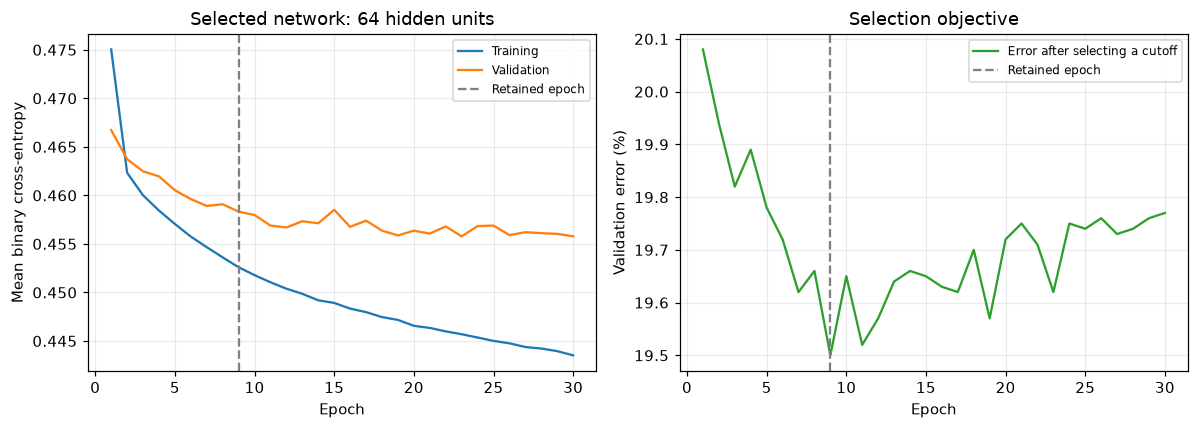

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(selected_history["Epoch"], selected_history["Training loss"], label="Training")
axes[0].plot(selected_history["Epoch"], selected_history["Validation loss"], label="Validation")
axes[0].set(
    xlabel="Epoch", ylabel="Mean binary cross-entropy",
    title=f"Selected network: {selected_width} hidden units"
)
axes[1].plot(
    selected_history["Epoch"], 100 * selected_history["Validation error"],
    color="tab:green", label="Error after selecting a cutoff"
)
axes[1].set(xlabel="Epoch", ylabel="Validation error (%)", title="Selection objective")
for ax in axes:
    ax.axvline(selected_epoch, color="gray", linestyle="--", label="Retained epoch")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Comparison models

KNN uses equal votes and Euclidean distance on the common standardized/one-hot
features. I extend the earlier K grid through 1,001. I retrieve the largest
neighborhood in small validation batches and use cumulative positive counts
to evaluate each K; this avoids holding all neighbor indices at once.
Equal-distance ordering follows the library's returned ordering.

Logistic regression uses L2 regularization and seven C values from 0.01 to 10.
Smaller C means stronger shrinkage. For both models I select settings by the
fewest validation mistakes after cutoff selection, with ties favoring higher
AUC and then the smaller K or C. The new models use identical fitting and
selection rows. Lecture 6, pp. 4-5 and 10-14, discusses flexibility and shrinkage.

In [8]:
knn_search = KNeighborsClassifier(
    n_neighbors=max(K_VALUES), weights="uniform", metric="euclidean",
    algorithm="brute", n_jobs=1
).fit(X_train, y_train)
knn_probabilities = np.empty((len(y_validation), len(K_VALUES)), dtype=np.float64)
for start in range(0, len(y_validation), 512):
    stop = min(start + 512, len(y_validation))
    neighbors = knn_search.kneighbors(X_validation[start:stop], return_distance=False)
    positive_counts = np.cumsum(y_train[neighbors], axis=1, dtype=np.float64)
    for j, k in enumerate(K_VALUES):
        knn_probabilities[start:stop, j] = positive_counts[:, k - 1] / k
    if start == 0 or stop == len(y_validation) or start % 2560 == 0:
        print(f"KNN selection predictions: {stop:,}/{len(y_validation):,}", flush=True)

knn_rows = []
best_knn_rank = None
for j, k in enumerate(K_VALUES):
    probabilities = knn_probabilities[:, j]
    cutoff, error = choose_cutoff(y_validation, probabilities)
    auc = roc_auc_score(y_validation, probabilities)
    knn_rows.append({
        "K": k, "Validation error": error, "Cutoff": cutoff, "Validation AUC": auc
    })
    rank = (error, -auc, k)
    if best_knn_rank is None or rank < best_knn_rank:
        best_knn_rank = rank
        selected_k = k

logistic_rows = []
best_logistic_rank = None
for c in C_VALUES:
    logistic = LogisticRegression(C=c, max_iter=1000, random_state=SEED).fit(X_train, y_train)
    if logistic.n_iter_[0] >= logistic.max_iter:
        raise RuntimeError("Logistic regression did not converge.")
    probabilities = logistic.predict_proba(X_validation)[:, 1]
    cutoff, error = choose_cutoff(y_validation, probabilities)
    auc = roc_auc_score(y_validation, probabilities)
    logistic_rows.append({
        "C": c, "Validation error": error, "Cutoff": cutoff,
        "Validation AUC": auc, "Iterations": logistic.n_iter_[0]
    })
    rank = (error, -auc, c)
    if best_logistic_rank is None or rank < best_logistic_rank:
        best_logistic_rank = rank
        selected_c = c

knn_validation_results = pd.DataFrame(knn_rows)
logistic_validation_results = pd.DataFrame(logistic_rows)
print("KNN selection results:")
print(knn_validation_results.round(5).to_string(index=False))
print("\nLogistic selection results:")
print(logistic_validation_results.round(5).to_string(index=False))
del neighbors, positive_counts, knn_probabilities, knn_search, candidate, logistic

KNN selection predictions: 512/10,000


KNN selection predictions: 3,072/10,000


KNN selection predictions: 5,632/10,000


KNN selection predictions: 8,192/10,000


KNN selection predictions: 10,000/10,000


KNN selection results:
   K  Validation error  Cutoff  Validation AUC
   1            0.2026 1.00000         0.57239
   3            0.2026 1.00000         0.61787
   5            0.2014 0.80000         0.63804
   9            0.1991 0.55556         0.66536
  15            0.1973 0.53333         0.68634
  21            0.1976 0.52381         0.69306
  31            0.1981 0.61290         0.69819
  51            0.1974 0.50980         0.70904
 101            0.1973 0.45545         0.71132
 201            0.1989 0.46766         0.70789
 301            0.1986 0.46512         0.70422
 501            0.2000 0.43713         0.70057
 701            0.1999 0.46362         0.69834
1001            0.2005 0.43357         0.69629

Logistic selection results:
    C  Validation error  Cutoff  Validation AUC  Iterations
 0.01            0.2011 0.40687         0.69470          46
 0.03            0.2007 0.41387         0.69487          67
 0.10            0.2006 0.42039         0.69463          92
 0.

## Lock model settings before final fitting

The table below identifies each selected configuration. A provisional validation
cutoff is used to score configurations, but it is not transferred to the refitted
model. The new calibration sample will choose that final cutoff. I also identify
the model family preferred on the selection sample, with ties favoring higher
AUC and then the table's order. That preference is fixed before calibration
and testing. Both historical networks retain their own previously locked choices.

In [9]:
selected_knn_summary = knn_validation_results.loc[
    knn_validation_results["K"] == selected_k
].iloc[0]
selected_logistic_summary = logistic_validation_results.loc[
    logistic_validation_results["C"] == selected_c
].iloc[0]
selection_results = pd.DataFrame([
    {"Model": name, "Validation error": row["Validation error"],
     "Validation AUC": row["Validation AUC"]}
    for name, row in [
        ("Final NN", selected_network_summary),
        ("KNN", selected_knn_summary), ("Logistic regression", selected_logistic_summary)
    ]
])
preferred_model = selection_results.sort_values(
    ["Validation error", "Validation AUC"], ascending=[True, False], kind="stable"
).iloc[0]["Model"]
model_choices = {
    "NN hidden width": selected_width, "NN learning rate": selected_learning_rate,
    "NN weight decay": selected_weight_decay, "NN epochs": selected_epoch,
    "KNN K": selected_k, "Logistic C": selected_c,
    "Validation-preferred family": preferred_model
}
print(selection_results.round(5).to_string(index=False))
print("Locked model settings:", model_choices)

              Model  Validation error  Validation AUC
           Final NN            0.1950         0.70884
                KNN            0.1973         0.71132
Logistic regression            0.2003         0.69457
Locked model settings: {'NN hidden width': 64, 'NN learning rate': 0.05, 'NN weight decay': 3e-05, 'NN epochs': 9, 'KNN K': 101, 'Logistic C': 0.3, 'Validation-preferred family': 'Final NN'}


## Final fitting and historical references

I refit the selected new models on training plus model-selection rows, following
the earlier final-fitting approach. Scaling and category levels are learned
on those combined rows only. The new network starts from seed 42 and trains
for its retained epoch count. Calibration and test rows remain outside all fits.

The original network uses its original 105,000 rows, 64 hidden units, 25 epochs,
SGD learning rate 0.05, momentum 0.9, L2 penalty 0.0001, and batch size 256.
The first revision uses its previous 305,000 rows and the same settings except
40 epochs. Their fixed cutoffs are 0.5622760653 and 0.4935349822. Each historical
network learns its own preprocessing on its own original fitting rows. Neither
is retuned on the new holdouts. The earlier curve describes selection, not refitting.

In [10]:
def fit_fixed_network(predictors, labels, hidden_width, epochs, learning_rate,
                      weight_decay, batch_size, name):
    torch.manual_seed(SEED)
    network = make_network(predictors.shape[1], hidden_width)
    optimizer = make_optimizer(network, learning_rate, weight_decay)
    generator = torch.Generator().manual_seed(SEED)
    for epoch in range(1, epochs + 1):
        train_epoch(network, predictors, labels, optimizer, generator, batch_size)
        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"{name} final fit: epoch {epoch}/{epochs}", flush=True)
    return network

reference_final_training = add_features(reference_final_training)
reference_scaler, reference_encoder = fit_preprocessing(reference_final_training)
X_reference = transform_predictors(reference_final_training, reference_scaler, reference_encoder)
y_reference = reference_final_training["DepDel15"].to_numpy(dtype=np.float32)
reference_network = fit_fixed_network(
    X_reference, y_reference, 64, 25, 0.05, 0.0001, 256, "Original NN"
)

previous_final_training = add_features(previous_final_training)
previous_scaler, previous_encoder = fit_preprocessing(previous_final_training)
X_previous = transform_predictors(previous_final_training, previous_scaler, previous_encoder)
y_previous = previous_final_training["DepDel15"].to_numpy(dtype=np.float32)
previous_network = fit_fixed_network(
    X_previous, y_previous, 64, 40, 0.05, 0.0001, 256, "Previous NN"
)

final_training = pd.concat([training_data, validation_data])
final_scaler, final_encoder = fit_preprocessing(final_training)
X_final = transform_predictors(final_training, final_scaler, final_encoder)
y_final = final_training["DepDel15"].to_numpy(dtype=np.float32)
final_network = fit_fixed_network(
    X_final, y_final, selected_width, selected_epoch, selected_learning_rate,
    selected_weight_decay, BATCH_SIZE, "Final NN"
)
final_knn = KNeighborsClassifier(
    n_neighbors=selected_k, weights="uniform", metric="euclidean",
    algorithm="brute", n_jobs=1
).fit(X_final, y_final)
final_logistic = LogisticRegression(
    C=selected_c, max_iter=1000, random_state=SEED
).fit(X_final, y_final)
if final_logistic.n_iter_[0] >= final_logistic.max_iter:
    raise RuntimeError("Final logistic regression did not converge.")

calibration_data = add_features(calibration_data)
X_calibration = transform_predictors(calibration_data, final_scaler, final_encoder)
y_calibration = calibration_data["DepDel15"].to_numpy(dtype=np.float32)
calibration_probabilities = {
    "Final NN": torch.sigmoid(
        torch.from_numpy(predict_logits(final_network, X_calibration))
    ).numpy(),
    "KNN": final_knn.predict_proba(X_calibration)[:, 1],
    "Logistic regression": final_logistic.predict_proba(X_calibration)[:, 1]
}
assert final_training.index.intersection(calibration_data.index).empty
assert final_training.index.intersection(test_data.index).empty
print("Final fitting rows:", len(final_training))
del X_reference, X_previous, y_reference, y_previous

Original NN final fit: epoch 1/25


Original NN final fit: epoch 10/25


Original NN final fit: epoch 20/25


Original NN final fit: epoch 25/25


Previous NN final fit: epoch 1/40


...

Previous NN final fit: epoch 30/40


Previous NN final fit: epoch 40/40


Final NN final fit: epoch 1/9


Final NN final fit: epoch 9/9


Final fitting rows: 537748


## Calibrate cutoffs, then lock all choices

The untouched fitting holdout below chooses each new model's cutoff to minimize
equal-cost mistakes. This is threshold calibration, not probability calibration.
A prediction is 1 when `probability > cutoff`, with equality assigned to 0.
Candidates are distinct probabilities plus 0, 0.5, and 1. Ties favor the cutoff
closest to 0.5 and then the smaller cutoff. The target remains a 15-minute delay.

Calibration does not change model settings, epochs, weights, or the previously
selected model-family preference. The calibration sample's reported error is
optimistic for its chosen cutoff; final test error assesses the locked procedure.
No class weighting, asymmetric cost, or required minimum recall is introduced.

In [11]:
cutoffs = {"Original NN": 0.5622760653495789, "Previous NN": 0.49353498220443726}
calibration_rows = []
for name, probabilities in calibration_probabilities.items():
    cutoff, error = choose_cutoff(y_calibration, probabilities)
    cutoffs[name] = cutoff
    calibration_rows.append({
        "Model": name, "Cutoff": cutoff, "Calibration error": error,
        "Calibration AUC": roc_auc_score(y_calibration, probabilities)
    })
calibration_results = pd.DataFrame(calibration_rows)
print(calibration_results.round(5).to_string(index=False))
locked_choices = {
    **model_choices, "Training rows": len(training_data),
    "Final fitting rows": len(final_training), "Cutoffs": cutoffs.copy()
}
print("All choices locked before testing:", locked_choices)

              Model  Cutoff  Calibration error  Calibration AUC
           Final NN 0.50007             0.1976          0.70504
                KNN 0.44554             0.1960          0.71297
Logistic regression 0.50767             0.2020          0.68080
All choices locked before testing: {'NN hidden width': 64, 'NN learning rate': 0.05, 'NN weight decay': 3e-05, 'NN epochs': 9, 'KNN K': 101, 'Logistic C': 0.3, 'Validation-preferred family': 'Final NN', 'Training rows': 527748, 'Final fitting rows': 537748, 'Cutoffs': {'Original NN': 0.5622760653495789, 'Previous NN': 0.49353498220443726, 'Final NN': 0.5000749826431274, 'KNN': 0.44554455445544555, 'Logistic regression': 0.5076709985733032}}


## Test evaluation

Test error is the fraction of incorrect class predictions. For binary 0/1
predictions, test MSE equals this error rate, as in HW2. AUC uses the predicted
probabilities and measures ranking; it does not depend on the selected cutoff.
Precision measures how many predicted delayed flights were delayed, while recall
measures how many delayed flights were detected. Confusion matrices have true
classes in rows and predicted classes in columns, ordered 0, 1. The figure
labels '<15 min' and '15+ min' refer to the target: class 0 includes
early/on-time departures and delays below 15 minutes; class 1 starts at 15 minutes.

Always predicting no delay is the training-majority reference. Its test error
is the test delayed fraction. I compare against it because a low error can hide
poor detection of delays. Classification concepts follow Lecture 5, pp. 14-19,
and continue the HW2 evaluation.

In [12]:
test_data = add_features(test_data)
X_test = transform_predictors(test_data, final_scaler, final_encoder)
X_reference_test = transform_predictors(test_data, reference_scaler, reference_encoder)
X_previous_test = transform_predictors(test_data, previous_scaler, previous_encoder)
y_test = test_data["DepDel15"].to_numpy(dtype=np.float32)
test_probabilities = {
    "Original NN": torch.sigmoid(
        torch.from_numpy(predict_logits(reference_network, X_reference_test))
    ).numpy(),
    "Previous NN": torch.sigmoid(
        torch.from_numpy(predict_logits(previous_network, X_previous_test))
    ).numpy(),
    "Final NN": torch.sigmoid(
        torch.from_numpy(predict_logits(final_network, X_test))
    ).numpy(),
    "KNN": final_knn.predict_proba(X_test)[:, 1],
    "Logistic regression": final_logistic.predict_proba(X_test)[:, 1]
}
for table in [reference_final_training, previous_final_training, final_training]:
    assert table.index.intersection(test_data.index).empty
for probabilities in test_probabilities.values():
    assert np.isfinite(probabilities).all()
    assert ((probabilities >= 0) & (probabilities <= 1)).all()
print("Common final test flights:", len(test_data))

Common final test flights: 10000


In [13]:
assert y_final.mean() < 0.5
test_rows = []
for name, probabilities in test_probabilities.items():
    for cutoff_name, cutoff in [("0.5", 0.5), ("Selected/fixed", cutoffs[name])]:
        predictions = (probabilities > cutoff).astype(int)
        error = np.mean(predictions != y_test)
        test_rows.append({
            "Model": name, "Cutoff rule": cutoff_name, "Cutoff": cutoff,
            "Test error": error, "Test MSE": np.mean((predictions - y_test) ** 2),
            "AUC": roc_auc_score(y_test, probabilities),
            "Precision": precision_score(y_test, predictions, zero_division=0),
            "Recall": recall_score(y_test, predictions, zero_division=0)
        })
test_results = pd.DataFrame(test_rows)
print(test_results.round(5).to_string(index=False))
print("\nAlways predict no delay:")
print(f"Test error = {y_test.mean():.2%}; recall = 0%; constant-score AUC = 0.5.")
print("Precision is reported as 0 when no positive prediction is made.")

              Model    Cutoff rule  Cutoff  Test error  Test MSE     AUC  Precision  Recall
        Original NN            0.5 0.50000      0.2016    0.2016 0.70591    0.50641 0.19497
        Original NN Selected/fixed 0.56228      0.1975    0.1975 0.70591    0.55050 0.13722
        Previous NN            0.5 0.50000      0.1973    0.1973 0.71315    0.55532 0.13129
        Previous NN Selected/fixed 0.49353      0.1968    0.1968 0.71315    0.55709 0.13968
           Final NN            0.5 0.50000      0.1974    0.1974 0.71120    0.57429 0.09921
           Final NN Selected/fixed 0.50007      0.1974    0.1974 0.71120    0.57429 0.09921
                KNN            0.5 0.50000      0.1970    0.1970 0.71170    0.61864 0.07206
                KNN Selected/fixed 0.44554      0.1979    0.1979 0.71170    0.55427 0.11846
Logistic regression            0.5 0.50000      0.2009    0.2009 0.68577    0.60000 0.02517
Logistic regression Selected/fixed 0.50767      0.2008    0.2008 0.68577    0.61

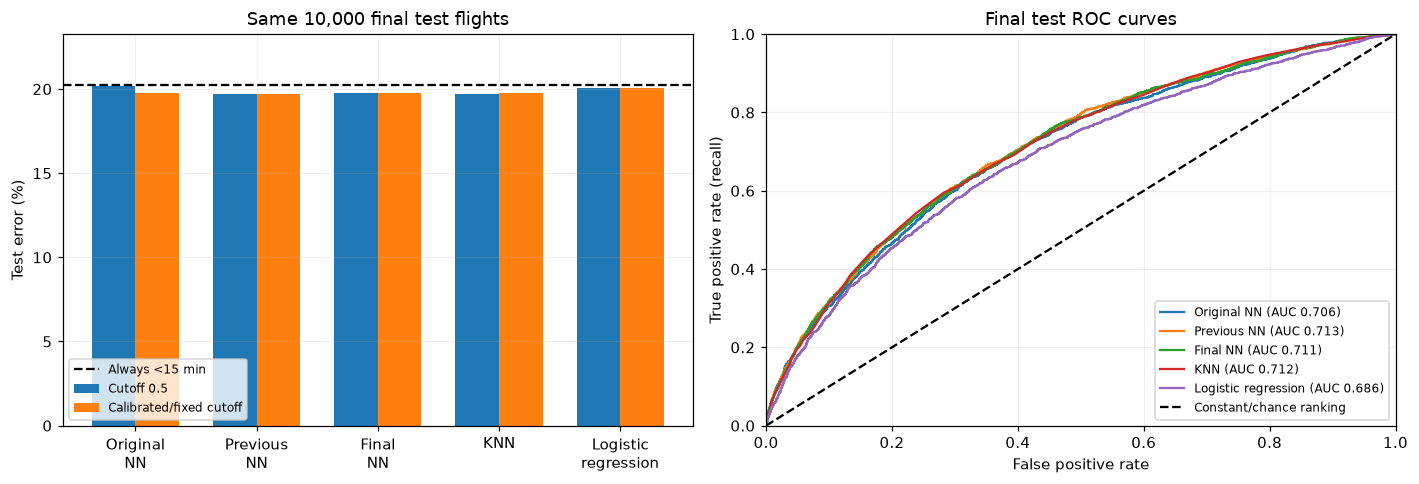

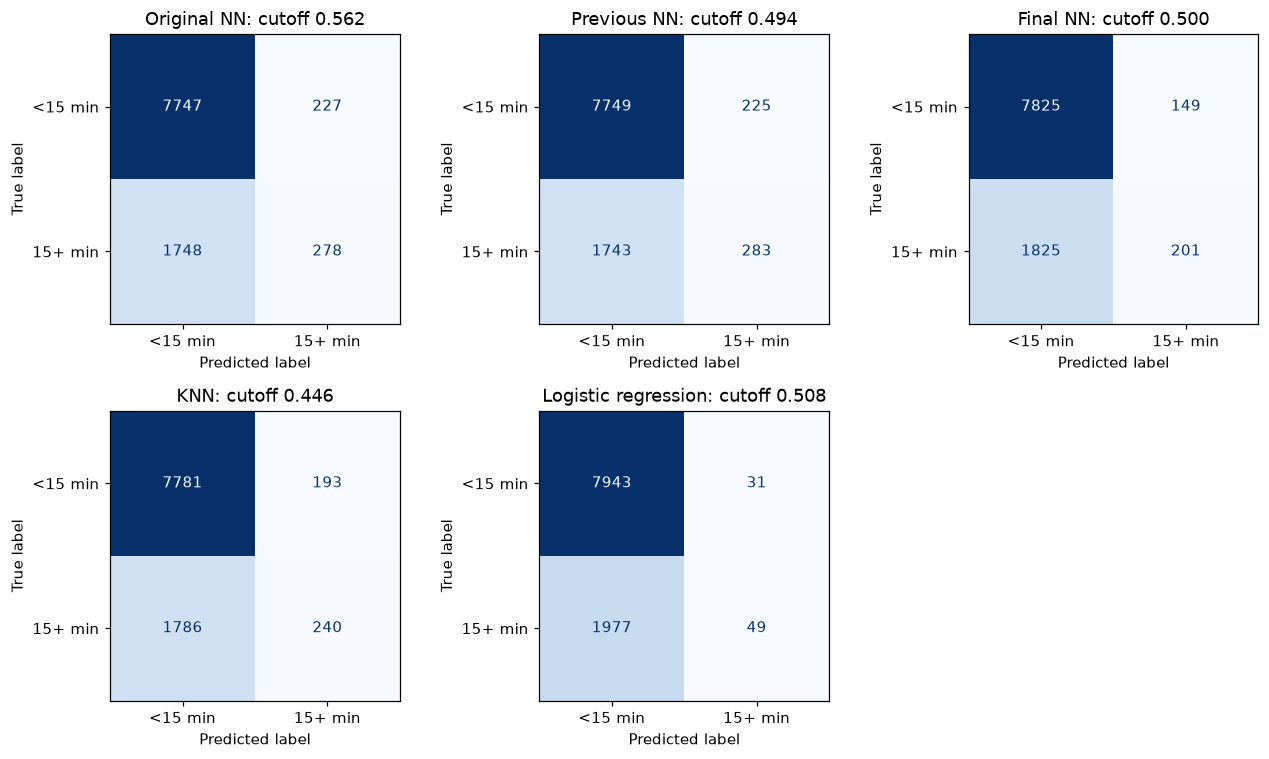

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
model_names = list(test_probabilities)
positions = np.arange(len(model_names))
default_results = test_results[test_results["Cutoff rule"] == "0.5"]
default_results = default_results.set_index("Model").loc[model_names]
selected_results = test_results[test_results["Cutoff rule"] == "Selected/fixed"]
selected_results = selected_results.set_index("Model").loc[model_names]
axes[0].bar(
    positions - 0.18, 100 * default_results["Test error"], width=0.36, label="Cutoff 0.5"
)
axes[0].bar(
    positions + 0.18, 100 * selected_results["Test error"], width=0.36,
    label="Calibrated/fixed cutoff"
)
axes[0].axhline(100 * y_test.mean(), color="black", linestyle="--", label="Always <15 min")
axes[0].set_xticks(
    positions, ["Original\nNN", "Previous\nNN", "Final\nNN", "KNN", "Logistic\nregression"]
)
axes[0].set(
    ylabel="Test error (%)", title=f"Same {len(y_test):,} final test flights",
    ylim=(0, 100 * max(test_results["Test error"].max(), y_test.mean()) + 3)
)
axes[0].legend(fontsize=8)
for name, probabilities in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, probabilities):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Constant/chance ranking")
axes[1].set(
    xlabel="False positive rate", ylabel="True positive rate (recall)",
    title="Final test ROC curves", xlim=(0, 1), ylim=(0, 1)
)
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (name, probabilities) in zip(axes.ravel(), test_probabilities.items()):
    predictions = (probabilities > cutoffs[name]).astype(int)
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=["<15 min", "15+ min"]).plot(
        ax=ax, colorbar=False, values_format="d", cmap="Blues"
    )
    ax.set_title(f"{name}: cutoff {cutoffs[name]:.3f}")
fig.delaxes(axes.ravel()[-1])
fig.tight_layout()
plt.show()

## Discussion of this run

The discussion below is calculated from this notebook's outputs, so changing
sample sizes or model settings does not leave stale metric values in the prose.
The best observed test result is descriptive; it is not used to choose or refit
another model.

In [15]:
nn_result = selected_results.loc["Final NN"]
first_loss = selected_history["Training loss"].iloc[0]
last_loss = selected_history["Training loss"].iloc[-1]
retained_row = selected_history.loc[selected_history["Epoch"] == selected_epoch].iloc[0]
paragraphs = [
    f"**Data and fitting.** There were {len(clean_data):,} complete records. "
    f"Selection used {len(training_data):,} training rows and "
    f"{len(validation_data):,} validation rows. Final new-model fits used "
    f"{len(final_training):,} rows; cutoffs used {len(calibration_data):,} "
    f"separate calibration rows. All five models used the same "
    f"{len(test_data):,} new test rows, with delayed fraction {y_test.mean():.2%}.",
    f"**Selection and training.** Equal-cost validation error selected "
    f"{selected_width} hidden units, learning rate {selected_learning_rate}, "
    f"L2 {selected_weight_decay}, and epoch {selected_epoch}. Its selection "
    f"error was {retained_row['Validation error']:.2%}, cross-entropy "
    f"{retained_row['Validation loss']:.4f}, and AUC "
    f"{retained_row['Validation AUC']:.4f}. Epoch-average training loss "
    f"changed from {first_loss:.4f} to {last_loss:.4f} over "
    f"{len(selected_history)} epochs. The retained checkpoint and stopping "
    f"epoch may differ: the best observed checkpoint is restored.",
    f"**Validation preference.** The model-selection sample preferred "
    f"{preferred_model}. This preference was fixed before cutoff calibration "
    f"and final testing; observing a different test winner does not revise it."
]
for name, row in selected_results.iterrows():
    paragraphs.append(
        f"**{name}.** At cutoff {row['Cutoff']:.4f}, test error was "
        f"{row['Test error']:.2%}, AUC {row['AUC']:.4f}, precision "
        f"{row['Precision']:.2%}, and recall {row['Recall']:.2%}."
    )
for name in ["Original NN", "Previous NN"]:
    reference = selected_results.loc[name]
    error_change = 100 * (nn_result["Test error"] - reference["Test error"])
    auc_change = nn_result["AUC"] - reference["AUC"]
    paragraphs.append(
        f"**Final NN versus {name}.** Error changed by "
        f"{error_change:+.2f} percentage points (negative favors the final NN), "
        f"and AUC by {auc_change:+.4f}. This matched comparison includes "
        f"changes to training size, model selection, and cutoff calibration "
        f"together; it does not isolate their individual effects."
    )
previous_result = selected_results.loc["Previous NN"]
if (nn_result["Test error"] >= previous_result["Test error"]
        and nn_result["AUC"] <= previous_result["AUC"]):
    paragraphs.append(
        "**Outcome of the final search.** The newly selected NN did not "
        "improve the previous NN's error or ranking on this holdout. The "
        "previous fitted model is preserved in this notebook. These results "
        "do not justify replacing it on performance grounds. The final "
        "search's validation choice remains reported as selected; the test "
        "result was not used to retune it or estimate a new winning model."
    )
else:
    paragraphs.append(
        "**Outcome of the final search.** At least one of the NN's observed "
        "error or ranking metrics improved relative to the previous NN. "
        "The full metric comparison is needed to assess tradeoffs; one "
        "holdout does not establish a universally better model."
    )
paragraphs.append(
    f"The final NN reduced error by "
    f"{100 * (y_test.mean() - nn_result['Test error']):+.2f} percentage points "
    f"relative to always predicting <15 minutes. Its recall of "
    f"{nn_result['Recall']:.2%} shows how many actual delayed flights were "
    f"detected. Equal-cost error minimization can still leave many delays missed."
)
paragraphs.append(
    f"Among the calibrated/fixed cutoffs, "
    f"{selected_results['Test error'].idxmin()} had the lowest observed test "
    f"error and {selected_results['AUC'].idxmax()} had the highest AUC. "
    f"These are descriptive results from one random holdout, without a "
    f"significance test or a guarantee for future months. No further tuning "
    f"used the test results."
)
if selected_k == max(K_VALUES):
    paragraphs.append("KNN selected the grid's largest K; the optimum beyond it is unknown.")
if selected_epoch == MAX_EPOCHS:
    paragraphs.append("The selected NN reached the epoch limit; its optimum beyond it is unknown.")
paragraphs.append(
    "This is the best NN in the declared final search under its validation "
    "rule. It does not prove the best attainable performance within the "
    "whole assignment scope."
)
display(Markdown("\n\n".join(paragraphs)))

**Data and fitting.** There were 592,748 complete records. Selection used 527,748 training rows and 10,000 validation rows. Final new-model fits used 537,748 rows; cutoffs used 10,000 separate calibration rows. All five models used the same 10,000 new test rows, with delayed fraction 20.26%.

**Selection and training.** Equal-cost validation error selected 64 hidden units, learning rate 0.05, L2 3e-05, and epoch 9. Its selection error was 19.50%, cross-entropy 0.4583, and AUC 0.7088. Epoch-average training loss changed from 0.4750 to 0.4435 over 30 epochs. The retained checkpoint and stopping epoch may differ: the best observed checkpoint is restored.

**Validation preference.** The model-selection sample preferred Final NN. This preference was fixed before cutoff calibration and final testing; observing a different test winner does not revise it.

**Original NN.** At cutoff 0.5623, test error was 19.75%, AUC 0.7059, precision 55.05%, and recall 13.72%.

**Previous NN.** At cutoff 0.4935, test error was 19.68%, AUC 0.7131, precision 55.71%, and recall 13.97%.

**Final NN.** At cutoff 0.5001, test error was 19.74%, AUC 0.7112, precision 57.43%, and recall 9.92%.

**KNN.** At cutoff 0.4455, test error was 19.79%, AUC 0.7117, precision 55.43%, and recall 11.85%.

**Logistic regression.** At cutoff 0.5077, test error was 20.08%, AUC 0.6858, precision 61.25%, and recall 2.42%.

**Final NN versus Original NN.** Error changed by -0.01 percentage points (negative favors the final NN), and AUC by +0.0053. This matched comparison includes changes to training size, model selection, and cutoff calibration together; it does not isolate their individual effects.

**Final NN versus Previous NN.** Error changed by +0.06 percentage points (negative favors the final NN), and AUC by -0.0020. This matched comparison includes changes to training size, model selection, and cutoff calibration together; it does not isolate their individual effects.

**Outcome of the final search.** The newly selected NN did not improve the previous NN's error or ranking on this holdout. The previous fitted model is preserved in this notebook. These results do not justify replacing it on performance grounds. The final search's validation choice remains reported as selected; the test result was not used to retune it or estimate a new winning model.

The final NN reduced error by +0.52 percentage points relative to always predicting <15 minutes. Its recall of 9.92% shows how many actual delayed flights were detected. Equal-cost error minimization can still leave many delays missed.

Among the calibrated/fixed cutoffs, Previous NN had the lowest observed test error and Previous NN had the highest AUC. These are descriptive results from one random holdout, without a significance test or a guarantee for future months. No further tuning used the test results.

This is the best NN in the declared final search under its validation rule. It does not prove the best attainable performance within the whole assignment scope.

## Limits and practical meaning

These results describe random row splits of the supplied CSV. They do not
demonstrate future-month accuracy, verify April coverage, or establish flight
independence. The new test excludes prior selected classification rows, but
HW1/HW2 and both earlier HW3 runs already informed the study. It is not a wholly
new external dataset. Different HW1/HW2 test samples prevent direct performance
claims across homeworks; HW1 also predicts minutes rather than this binary label.

Missing-delay records are excluded for unknown reasons. Repeated recorded rows
remain, and the missing-only rule retains one physically invalid negative
scheduled duration. The seven predictors omit weather, operational disruptions,
and measured congestion. No cleaning or additional source fields were introduced.

The final search changes sample size, width, stopping, model-selection objective,
batch size, and threshold calibration together. It cannot attribute a gain to
one of these changes. Selection across configurations and epochs can overfit the
selection sample; independent calibration and testing assess later stages.
The calibration error is optimistic for its selected cutoff. This finite search
does not establish an absolute optimum or a performance ceiling.

The target and equal-cost objective are unchanged. Passenger warnings would need
an agreed relative cost for missed delays and false warnings; no such cost,
class weighting, or minimum recall has been assumed. Small error gains or higher
AUC alone do not establish reliable warnings. Associations are not causal effects
of airlines, airports, or departure time. The final test is reported once, with
no further tuning based on its result.

## References

- Assignment: `README.md`, Problem 2 and Submission.
- [BTS Reporting Carrier On-Time Performance field dictionary](https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FGJ): target, time, duration, and distance definitions.
- Supplied `06-model selection.pdf`: pp. 2-5 (evaluation/flexibility), pp. 10-14 (regularization and scaling).
- Supplied `07-nonlinear.pdf`: pp. 3-5 (basis and step functions).
- Supplied `08-neural networks.pdf`: pp. 4-7 (MLPs and optimization), pp. 8-9 and 12 (cross-entropy), p. 14 (binary sigmoid output), p. 16 (ReLU).
- Previously supplied `05-classification.pdf`: pp. 14-19 (KNN and classification metrics).
- [PyTorch BCEWithLogitsLoss documentation](https://docs.pytorch.org/docs/2.14/generated/torch.nn.BCEWithLogitsLoss.html): stable sigmoid/binary-cross-entropy implementation.
- [PyTorch SGD documentation](https://docs.pytorch.org/docs/2.14/generated/torch.optim.SGD.html): momentum and L2 weight decay.
- [scikit-learn OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) and [common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html): category encoding and training-only preprocessing.
- [scikit-learn logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) and [KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html): comparison-model APIs.

All fitted models use standard libraries, as permitted for this data-analysis
task in HW1/HW2. The separate from-scratch function requirements of those homeworks
do not apply to HW3's PyTorch notebook. No test files or previous homework files
are changed. Submit both HW3 notebooks and the required CSV through the assignment
repository; GitHub/Gradescope submission is a separate step.